In [147]:
# import libraries
from lightgbm import LGBMRegressor
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [148]:
train_data_path = "sift_new_train_data.csv"
test_data_path = "sift_new_test_data.csv"
calib_data_path = "ivf_calibration_sift.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)
calib_data = pd.read_csv(calib_data_path)

train_data = train_data[train_data["index_acc"] == 70]
test_data = test_data[test_data["index_acc"] == 70]
calib_data = calib_data[calib_data["index_accuracy"] == 70]

In [149]:
################################################################################################
#################################### Dataset Generation ########################################
################################################################################################

In [153]:
def add_more_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds derived features to a raw scan log DataFrame.

    Assumes columns produced by ScanLogger.column_names():
        query_id, qi, k, nstep, ndis, ninsert, list_size,
        first_centroid_dist, d1, d2, d3, margin1, margin2,
        cdist_mean, cdist_std, peaked, current_centroid_dist,
        closestNN, furthestNN, avg, var, med, p25, p75, recall

    All groupby operations are over (query_id, k) so features are
    computed within a single query's probe sequence for a fixed k.
    """

    df = df.sort_values(["query_id", "k", "nstep"]).reset_index(drop=True)
    group = df.groupby(["query_id", "k"], sort=False)

    # ----------------------------------------------------------------
    # 1. Scan progress
    # ----------------------------------------------------------------
    df["step_index"]             = group.cumcount()
    df["cum_scanned_norm"]       = df["ndis"] / df.groupby("query_id")["ndis"].transform("max")
    df["frac_centroids_scanned"] = df["nstep"] / df.groupby("query_id")["nstep"].transform("max")
    df["probe_progress"]         = df["nstep"] / df["k"]

    # ----------------------------------------------------------------
    # 2. Insert / heap update dynamics
    # ----------------------------------------------------------------
    df["prev1_ninsert"] = group["ninsert"].shift(1).fillna(df["ninsert"])
    df["prev2_ninsert"] = group["ninsert"].shift(2).fillna(df["ninsert"])

    df["ninsert_diff_1"]      = df["ninsert"] - df["prev1_ninsert"]
    df["ninsert_diff_2"]      = df["ninsert"] - df["prev2_ninsert"]
    df["insert_acceleration"] = df["ninsert_diff_1"] - df["ninsert_diff_2"]

    df["insert_efficiency"]   = df["ninsert"] / (df["ndis"] + 1)
    df["coverage_gain"]       = df["ninsert_diff_1"] / (df["ninsert"] + 1)
    df["scan_redundancy"]     = df["ndis"] / (df["ninsert"] + 1)

    half_lookup = df.set_index(["query_id", "k", "step_index"])["ninsert"].to_dict()
    df["half_index"]   = (df["step_index"] // 2).astype(int)
    df["half_ninsert"] = [
        half_lookup.get((qid, k, h), np.nan)
        for qid, k, h in zip(df["query_id"], df["k"], df["half_index"])
    ]

    # ----------------------------------------------------------------
    # 4. Heap (kth distance) convergence
    # ----------------------------------------------------------------
    df["heap_convergence"]       = df["furthestNN"] - df["closestNN"]
    df["heap_convergence_rate"]  = group["heap_convergence"].diff()
    df["heap_convergence_rate"]  = df["heap_convergence_rate"].fillna(
        df.groupby(["query_id", "k"])["heap_convergence"].transform("max")
    )
    df["heap_convergence_accel"] = group["heap_convergence_rate"].diff()
    df["heap_convergence_accel"] = df["heap_convergence_accel"].fillna(
        df.groupby(["query_id", "k"])["heap_convergence_rate"].transform("max")
    )
    df["relative_heap_gain"]     = df["heap_convergence_rate"] / (df["heap_convergence"] + 1e-6)

    df["log_kth"]             = np.log(df["furthestNN"] + 1e-9)
    df["kth_improvement"] = group["log_kth"].diff()
    df["kth_improvement"] = df["kth_improvement"].fillna(
        df.groupby(["query_id", "k"])["log_kth"].transform("max")
    )
    df["kth_relative_change"] = group["furthestNN"].diff().fillna(0) / (df["furthestNN"] + 1e-8)
    df["delta_kth"]  = group["furthestNN"].diff(1)
    df["delta_kth"]  = df["delta_kth"].fillna(group["furthestNN"].transform("first"))
    
    df["heap_slope"] = group["furthestNN"].diff(3)
    df["heap_slope"] = df["heap_slope"].fillna(group["furthestNN"].transform("first"))

    # ----------------------------------------------------------------
    # 5. Centroid geometry ratios
    # ----------------------------------------------------------------
    df["centroid_dist_ratio"] = df["current_centroid_dist"] / (df["first_centroid_dist"] + 1e-8)
    df["centroid_confusion"]  = df["d1"] / (df["d2"] + 1e-6)
    df["boundary_sharpness"]  = (df["d3"] - df["d1"]) / (df["d1"] + 1e-6)

    # query hardness: how spread out are ALL centroids relative to nearest
    df["hardness_spread"]     = df["cdist_all_std"] / (df["first_centroid_dist"] + 1e-8)
    df["hardness_iqr"]        = (df["cdist_all_p75"] - df["cdist_all_p25"]) / (df["first_centroid_dist"] + 1e-8)
    df["global_peaked"]       = (df["cdist_all_mean"] - df["first_centroid_dist"]) / (df["cdist_all_mean"] + 1e-8)

    # ----------------------------------------------------------------
    # 6. Heap distribution shape
    # ----------------------------------------------------------------
    df["nn_cv"]      = df["heap_convergence"] / (df["avg"] + 1e-6)
    df["iqr"]        = df["p75"] - df["p25"]
    df["skew_proxy"] = (df["avg"] - df["med"]) / (df["avg"] + 1e-8)
    df["tail_ratio"] = df["furthestNN"] / (df["avg"] + 1e-8)

    # ----------------------------------------------------------------
    # 7. Cluster size features
    # ----------------------------------------------------------------
    df["log_list_size"]     = np.log(df["list_size"] + 1)
    df["list_size_vs_ndis"] = df["list_size"] / (df["ndis"] + 1)

    # ----------------------------------------------------------------
    # 8. Log-scale progress
    # ----------------------------------------------------------------
    df["log2_nprobe"] = np.log2(df["nstep"] + 1)
    df["log_ndis"]    = np.log(df["ndis"] + 1)

    # how many steps since last heap update — signals stagnation
    df["steps_since_insert"] = (
        df.groupby(["query_id", "k"])["ninsert_diff_1"]
        .transform(lambda s: s.eq(0).groupby((s.ne(0)).cumsum()).cumcount())
    )
    
    # ratio of current centroid dist to kth distance — 
    # if centroid is farther than kth, remaining clusters can't improve heap
    df["centroid_vs_kth"] = df["current_centroid_dist"] / (df["furthestNN"] + 1e-8)
    
    # cumulative insert rate decay — are we finding fewer neighbors over time?
    df["insert_rate_decay"] = df["ninsert_diff_1"] / (df["prev1_ninsert"] + 1)
    
    # kth distance relative to first centroid distance —
    # normalizes heap quality to query's local scale
    df["kth_vs_first_centroid"] = df["furthestNN"] / (df["first_centroid_dist"] + 1e-8)
    
    # how much kth has improved since start — total convergence so far
    first_kth = df.groupby(["query_id", "k"])["furthestNN"].transform("first")
    df["total_kth_improvement"] = (first_kth - df["furthestNN"]) / (first_kth + 1e-8)

    return df

In [154]:
train_data = add_more_features(train_data)
test_data = add_more_features(test_data)

In [155]:
def add_query_hardness(df):
    df = df.copy()
    records = []
    for (qid, k), g in df.groupby(["query_id", "k"]):
        g = g.sort_values("nstep")
        nsteps = g["nstep"].to_numpy()
        recalls = g["recall"].to_numpy()
        mask = recalls >= 80
        if mask.any():
            min_step = nsteps[np.argmax(mask)]
        else:
            min_step = nsteps[-1] + 1
        records.append((qid, k, min_step))
    step_df = pd.DataFrame(records, columns=["query_id", "k", "step_to_80"])

    hardness_score = (
        step_df
        .groupby("query_id")["step_to_80"]
        .max()
        .reset_index()
    )

    hardness_score = hardness_score.sort_values("step_to_80").reset_index(drop=True)
    n = len(hardness_score)
    easy_cut = int(0.45 * n)
    mid_cut  = int(0.85 * n)
    hardness_score["query_hardness"] = 3
    hardness_score.loc[:easy_cut-1, "query_hardness"] = 1
    hardness_score.loc[easy_cut:mid_cut-1, "query_hardness"] = 2
    df = df.merge(
        hardness_score[["query_id", "query_hardness"]],
        on="query_id",
        how="left"
    )
    return df

In [156]:
train_data = add_query_hardness(train_data)
test_data = add_query_hardness(test_data)

In [157]:
################################################################################################
#################################### Recall Prediction #########################################
################################################################################################

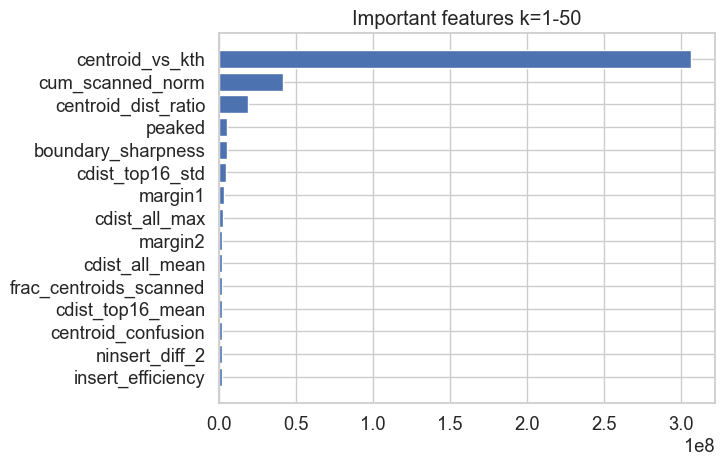

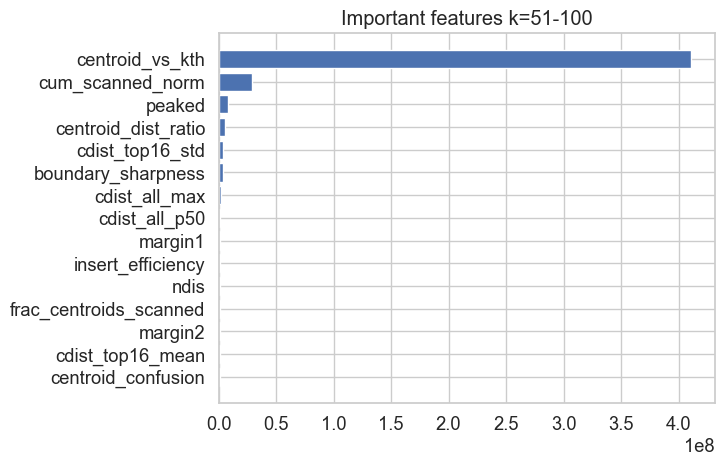

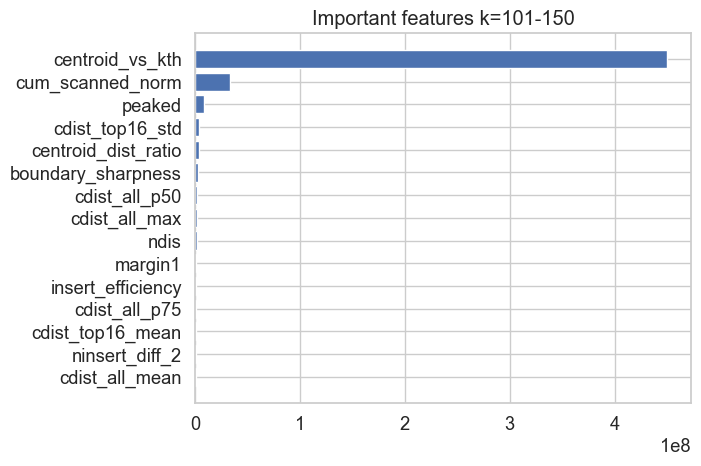

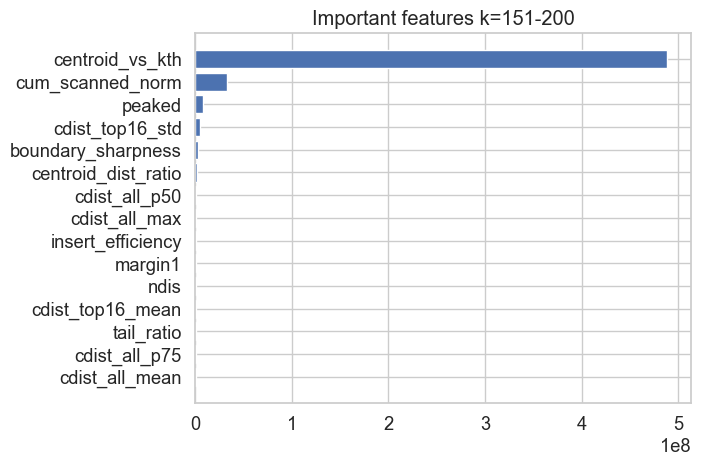

In [158]:
TARGET = "recall"
drop_cols = ["recall", "query_id", "index_acc", "step_index", "half_index", "query_hardness"]

def make_asymmetric_mse(alpha=4.0):
    """
    Penalizes over-predicting recall (y_pred > y_true) more heavily.
    Over-prediction = model thinks recall is high = terminates early = failure.
    """
    def asymmetric_mse(y_pred, dataset):
        y_true = dataset.get_label()
        residual = y_pred - y_true        # positive = over-predicted = dangerous
        grad = np.where(residual > 0, alpha * residual, residual)
        hess = np.where(residual > 0, np.full_like(residual, alpha), np.ones_like(residual))
        return grad, hess
    return asymmetric_mse

optimal_model = {}

for k_lo, k_hi in ((1, 50), (51, 100), (101, 150), (151, 200)):
    df = train_data[(train_data["k"] >= k_lo) & (train_data["k"] <= k_hi)]
    X_train = df.drop(columns=drop_cols)
    y_train = df[TARGET]

    train_set = lgb.Dataset(X_train, label=y_train)

    params = {
        "verbosity": -1,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "n_estimators": 500,
        # no "objective" here — custom fobj overrides it
    }

    model = lgb.train(
        params=params,
        train_set=train_set,
        num_boost_round=500,
        feval=make_asymmetric_mse(alpha=3.0),
    )

    # feature importance plot — same as before
    imp = model.feature_importance(importance_type="gain")
    cols = X_train.columns
    idx = np.argsort(imp)[-15:]
    plt.barh(cols[idx], imp[idx])
    plt.title(f"Important features k={k_lo}-{k_hi}")
    plt.show()

    optimal_model[(k_lo, k_hi)] = model

In [159]:
drop_cols = ["recall", "query_id", "index_acc", "step_index", "half_index", "query_hardness", "predicted_recall"]

In [160]:
def predict_bucketed(df_raw_test, optimal_model, drop_cols_test):
    preds = np.zeros(len(df_raw_test))
    for (k_lo, k_hi), model in optimal_model.items():
        mask = (df_raw_test["k"] >= k_lo) & (df_raw_test["k"] <= k_hi)
        subset = df_raw_test[mask]
        if len(subset) == 0:
            continue
        X = subset.drop(columns=drop_cols_test,errors="ignore")
        bucket_preds = model.predict(X)
        preds[mask.values] = bucket_preds
    return preds


In [161]:
test_data["predicted_recall"] = predict_bucketed(test_data, optimal_model, drop_cols)
print("mae: ", mean_absolute_error(test_data["recall"], test_data["predicted_recall"]))
print("r2: ", r2_score(test_data["recall"], test_data["predicted_recall"]))

mae:  1.845262126589495
r2:  0.9212615554362179


In [115]:
0.9997998690362746, 0.909976366740469, 0.91, 0.92

(0.9997998690362746, 0.909976366740469)

In [116]:
################################################################################################
##################################### Data Manipulation ########################################
################################################################################################

In [199]:
def get_actual_predicted_calibrated_nprobe(df, calib_data, prediction_offset=0.05):

    results, err1, err2 = [], [], []
    calib_lookup = calib_data.set_index(["k", "target_recall"])["nprobe"].to_dict()
    acc_lookup = df.set_index(["k", "query_id", "nstep"])["recall"].to_dict()
    grouped = {}
    for (qid, k), g in df.groupby(["query_id", "k"]):
        g = g.sort_values("nstep")
        grouped[(qid, k)] = (
            g["nstep"].to_numpy(),
            g["recall"].to_numpy(),
            g["predicted_recall"].to_numpy()
        )

    for target in range(50, 101, 5):
        target = float(target)
        for (qid, k), (nsteps, recalls, pred_recalls) in grouped.items():
            idx_actual = np.searchsorted(recalls, target, side="left")
            if idx_actual >= len(nsteps):
                err1.append((target, k, qid))
                actual_nprobe = nsteps[-1]
            else:
                actual_nprobe = nsteps[idx_actual]
            pred_target =  min(target * (1 + prediction_offset), 100.0)
            idx_pred = np.searchsorted(pred_recalls, pred_target, side="left")
            if idx_pred >= len(nsteps):
                err2.append((target, k, qid))
                predicted_nprobe = nsteps[-1]
            else:
                predicted_nprobe = nsteps[idx_pred]
            predicted_accuracy = acc_lookup.get((int(k), int(qid), int(predicted_nprobe)), 100)
            calibrated_nprobe = calib_lookup[(k, target)]
            calibrated_accuracy = acc_lookup.get((int(k), int(qid), int(calibrated_nprobe)), 100)
            results.append((
                qid, k, target,
                calibrated_accuracy,
                predicted_accuracy,
                actual_nprobe,
                calibrated_nprobe,
                predicted_nprobe
            ))
    return pd.DataFrame(results, columns=[
        "query_id", "k", "target_recall",
        "calibrated_recall", "predicted_recall",
        "actual_nprobe", "calibrated_nprobe", "predicted_nprobe"
    ]), err1, err2

In [229]:
features = ['query_id', 'k', 'nstep', 'recall', 'predicted_recall']
df = test_data[features]
stats, err1, err2 = get_actual_predicted_calibrated_nprobe(df, calib_data, 0.06)

In [230]:
################################################################################################
################################### Define Query Hardness ######################################
################################################################################################

In [231]:
mask = stats["target_recall"] == 100
percentiles = (
    stats.loc[mask]
         .groupby("k")["actual_nprobe"]
         .rank(method="first", pct=True)
)
hardness_labels = pd.cut(
    percentiles,
    bins=[0, 0.45, 0.85, 1.0],
    labels=["easy", "mid", "hard"],
    include_lowest=True
)
stats["hardness"] = None
stats.loc[mask, "hardness"] = hardness_labels
stats["hardness"] = (
    stats.groupby(["query_id","k"])["hardness"]
         .transform("first")
)

In [232]:
#stats.to_csv("gist_stats.csv", index=False)

In [233]:
################################################################################################
######################################## Data Analysis #########################################
################################################################################################

In [234]:
stats["calibration_success"] = (stats["calibrated_recall"] >= stats["target_recall"]).astype(int)
stats["darth_success"] = (stats["predicted_recall"] >= stats["target_recall"]).astype(int)

In [235]:
BUFFER = 0.05  # 5% relative buffer

stats["calibration_success"] = (
    stats["calibrated_recall"] >= stats["target_recall"] * (1 - BUFFER)
).astype(int)

stats["darth_success"] = (
    stats["predicted_recall"] >= stats["target_recall"] * (1 - BUFFER)
).astype(int)

In [236]:
group_cols = ["target_recall", "k", "hardness"]

In [237]:
agg_stats = stats.groupby(group_cols).agg(
    # ---------- CALIBRATION ----------
    calibration_success_percentage = ("calibration_success", lambda x: x.mean() * 100),
    calibration_average_nprobe = ("calibrated_nprobe", "mean"),
    calibration_average_recall = ("calibrated_recall", "mean"),

    # ---------- DARTH ----------
    predicted_success_percentage = ("darth_success", lambda x: x.mean() * 100),
    predicted_average_nprobe = ("predicted_nprobe", "mean"),
    predicted_average_recall = ("predicted_recall", "mean"),

    # useful sanity info
    total_samples = ("hardness", "count")
).reset_index()


In [238]:
agg_stats["hardness"] = pd.Categorical(
    agg_stats["hardness"],
    categories=["easy", "mid", "hard"],
    ordered=True
)

agg_stats = agg_stats.sort_values(["hardness", "target_recall"])


In [244]:
K = 10

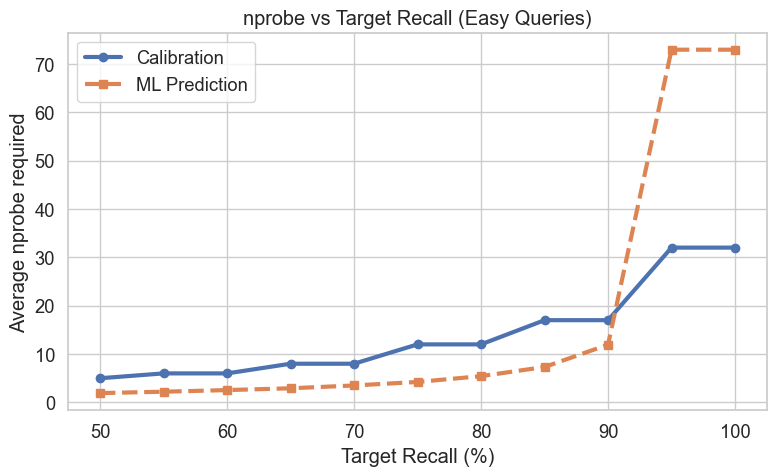

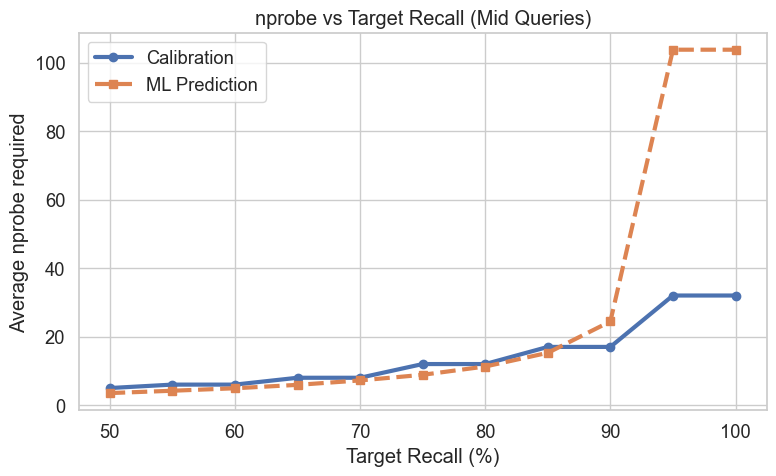

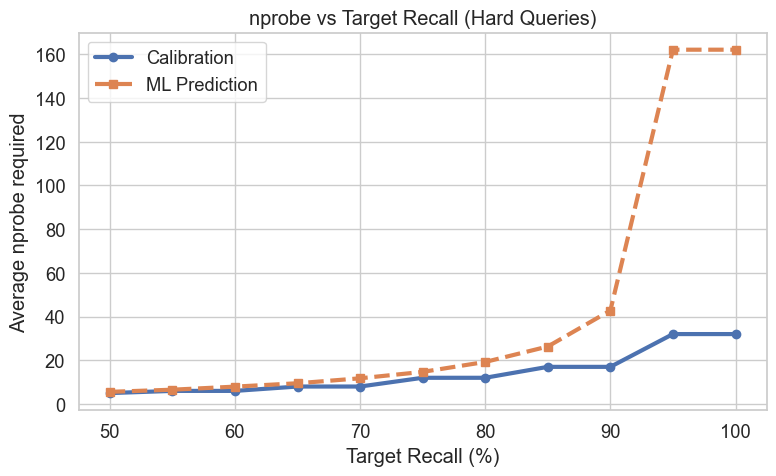

In [245]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

for hardness in ["easy", "mid", "hard"]:
    df = agg_stats[agg_stats["hardness"] == hardness]
    df = df[df["k"] == K]

    plt.figure(figsize=(8,5))

    plt.plot(df["target_recall"],
             df["calibration_average_nprobe"],
             marker="o",
             linewidth=3,
             label="Calibration")

    plt.plot(df["target_recall"],
             df["predicted_average_nprobe"],
             marker="s",
             linewidth=3,
             linestyle="--",
             label="ML Prediction")

    plt.title(f"nprobe vs Target Recall ({hardness.capitalize()} Queries)")
    plt.xlabel("Target Recall (%)")
    plt.ylabel("Average nprobe required")
    plt.legend()
    plt.tight_layout()
    plt.show()


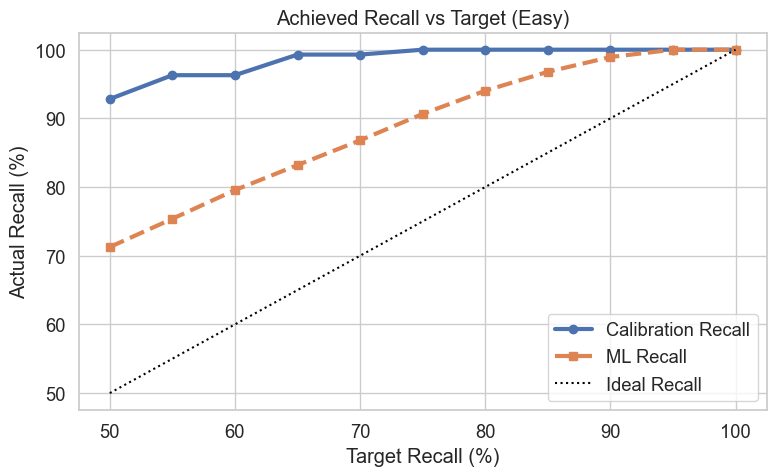

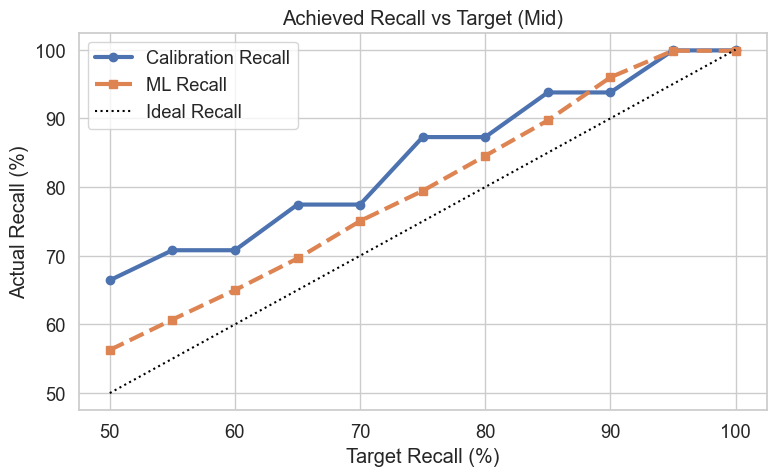

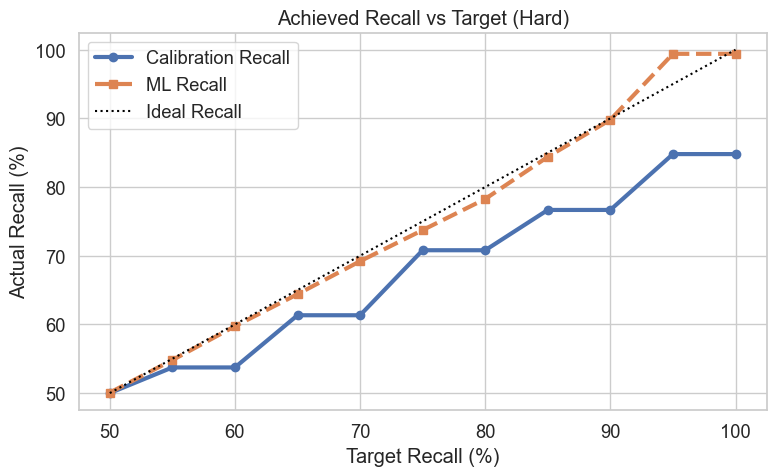

In [246]:
for hardness in ["easy", "mid", "hard"]:
    df = agg_stats[agg_stats["hardness"] == hardness]
    df = df[df["k"] == K]

    plt.figure(figsize=(8,5))

    plt.plot(df["target_recall"],
             df["calibration_average_recall"],
             marker="o",
             linewidth=3,
             label="Calibration Recall")

    plt.plot(df["target_recall"],
             df["predicted_average_recall"],
             marker="s",
             linewidth=3,
             linestyle="--",
             label="ML Recall")

    plt.plot(df["target_recall"],
             df["target_recall"],
             color="black",
             linestyle=":",
             label="Ideal Recall")

    plt.title(f"Achieved Recall vs Target ({hardness.capitalize()})")
    plt.xlabel("Target Recall (%)")
    plt.ylabel("Actual Recall (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()


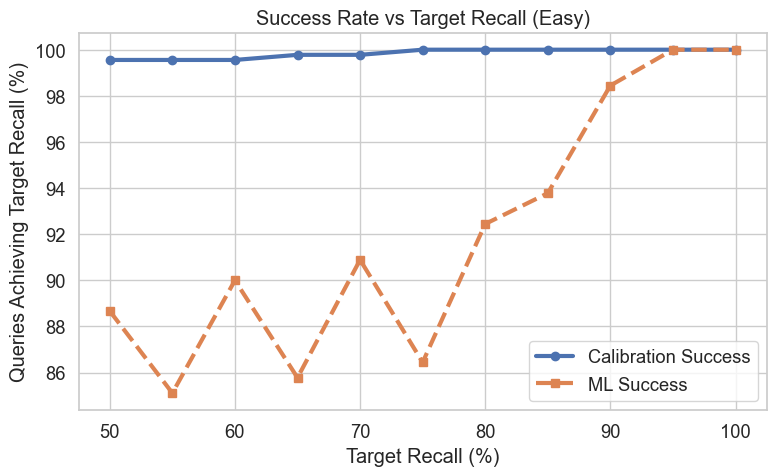

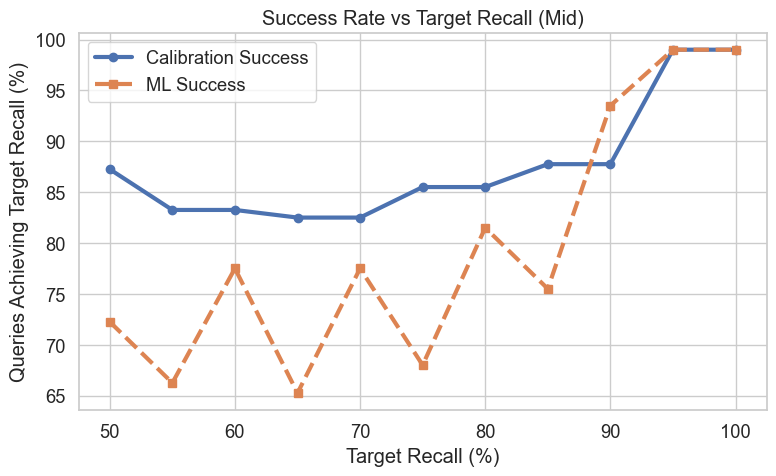

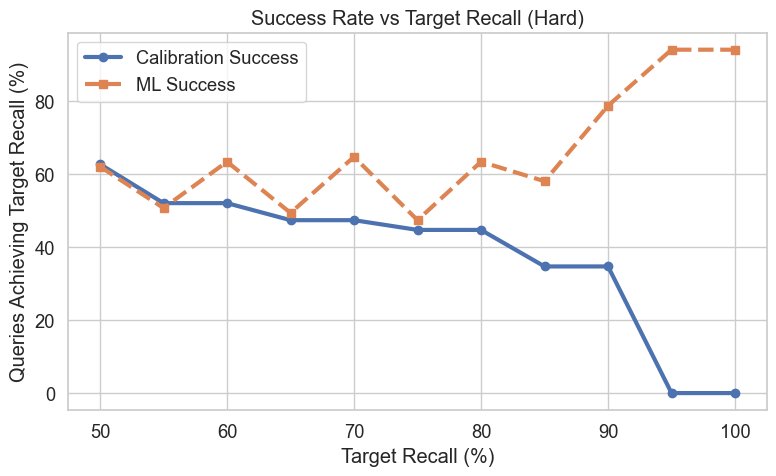

In [247]:
for hardness in ["easy", "mid", "hard"]:
    df = agg_stats[agg_stats["hardness"] == hardness]
    df = df[df["k"] == K]

    plt.figure(figsize=(8,5))

    plt.plot(df["target_recall"],
             df["calibration_success_percentage"],
             marker="o",
             linewidth=3,
             label="Calibration Success")

    plt.plot(df["target_recall"],
             df["predicted_success_percentage"],
             marker="s",
             linewidth=3,
             linestyle="--",
             label="ML Success")

    plt.title(f"Success Rate vs Target Recall ({hardness.capitalize()})")
    plt.xlabel("Target Recall (%)")
    plt.ylabel("Queries Achieving Target Recall (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()


/var/folders/3s/ntmw5bf137z9wj7r06y4s7jh0000gn/T/ipykernel_16544/3726528084.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nprobe_saving_%"] = (


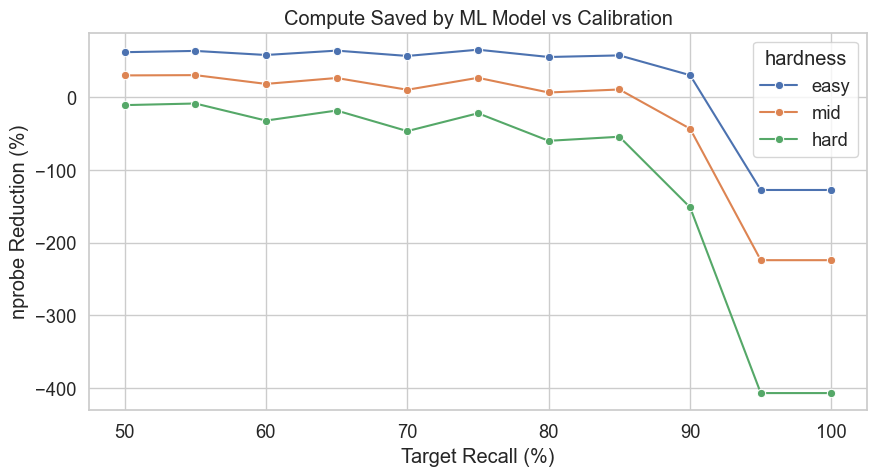

In [248]:
df = agg_stats[agg_stats["k"] == K]
df["nprobe_saving_%"] = (
    (df["calibration_average_nprobe"] -
     df["predicted_average_nprobe"])
    / df["calibration_average_nprobe"]
) * 100

plt.figure(figsize=(9,5))
sns.lineplot(
    data=df,
    x="target_recall",
    y="nprobe_saving_%",
    hue="hardness",
    marker="o"
)

plt.title("Compute Saved by ML Model vs Calibration")
plt.xlabel("Target Recall (%)")
plt.ylabel("nprobe Reduction (%)")
plt.tight_layout()
plt.show()
